In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(linewidth=200)      #to visualize clearly even bigger matrices in output


In [754]:
'''
Compute generalized tensor product, and remove nesting.
Removing nesting is necessary to represent Q_{s,s}, Q_{s,s+1}, Q_{s,s-1}
as single Numpy arrays,
and allow multiplications by these arrays and vectors, e.g. p_{s}.
'''

#GENERALIZED TENSOR PRODUCT BETWEEN A AND B MATRICES
def gentp(A, B):              
    p, q = np.shape(A)
    n, m = np.shape(B)

    if p > n or q > m:        #dimension check
        raise ValueError(f"Error of dimension\n{A} is {A.shape},\n{B} is {B.shape}")
    else :                                 #initialize T as an array of objects                                          
                                           #to store matrices as its entries,
                                           #as many as the entries of A
        T = np.empty((p, q), dtype=object) 
        for i in range(p):                                # i = 0,...,p-1
            for j in range(q):                            # j = 0,...,q-1
                T[i, j] = A[i, j] * B[ :n-i, :m-j]
    return T

#REMOVE NESTING FROM TENSOR
def flatten_tensor(nested_tensor):
    try:
        if isinstance(nested_tensor, np.ndarray):     #if input is a Numpy multi-dim array
            data = nested_tensor.tolist()             #put sub-arrays in a list
        else:
            data = nested_tensor
            
        return np.asarray(np.block(data),dtype=float)  #keep blocks, transform list in a single array
    
    except ValueError as e:
        raise ValueError(f"The blocks do not align geometrically: {e}")

#RETURN GENERALIZED TENSOR PRODUCT ALREADY FLATTEN
def tp(A,B):
    return flatten_tensor(gentp(A,B))

In [755]:
'''
Rates for the generator
'''

M = 50         #maximum population
C = 15         #healthcare threshold

b_1 = 5.0
mu_1 = 5.0
gamma_N1 = 6.0

params={'a_1': 5*b_1, 'a_2': 4*b_1, 'a_s': 2*b_1,
        'b_2': 5/4*b_1, 'b_s': 2*b_1,
        'mu_2': 4/5*mu_1, 'p_1': 0.2, 'p_2': 0.2,
        'gamma_N2': 5/4*gamma_N1,
        'gamma_T1': 3/2*gamma_N1, 'gamma_T2': 15/8*gamma_N1, }

a_1, a_2, a_s = params['a_1'], params['a_2'], params['a_s']
b_2, b_s = params['b_2'], params['b_s']
mu_2, p_1, p_2 = params['mu_2'], params['p_1'], params['p_2']
gamma_N2 = params['gamma_N2']
gamma_T1, gamma_T2 = params['gamma_T1'], params['gamma_T2']

#PROGRESSION RATE FUNCTION FROM I1 to I2
def nu_1(i):
  return (gamma_N1*i) + (gamma_T1*min(i,C))

#PROGRESSION RATE FUNCTION FROM I1 to I2
def nu_2(i):
  return (gamma_N2*i) + (gamma_T2*min(i,C))

#DELTA KROENECKER
def delta(x,y):
    if x==y:
        return 1
    else:
        return 0
        
#RATES q(s,(i_{1),i_{2}) COMPUTATION
def out_state(s, i_1, i_2):                                   #positive output
    return (
        i_1* (a_1 + b_1*(1-delta(s + i_1 + i_2, M))) +
        i_2*(a_2 + b_2*(1-delta(s + i_1 + i_2, M))) +
        s *(a_s + b_s*(1-delta(s + i_1 + i_2, M))) + 
        nu_1(i_1) + nu_2(i_2) + (mu_1*s*i_1) + (mu_2*s*i_2)
    )

#LIST OF GRADUALLY ORDERED q(s,(i_{1),i_{2}) GIVEN M,s
#e.g. for M=2,s=0: compute q(s,(i_{1),i_{2}) for entries (0,0,0),(0,0,1),(0,0,2),(0,1,0),(0,1,1),(0,2,0)
def ordered_states(s):
  L = list()
  for i in range(M-s+1):
    for j in range(M-s-i+1):
     L.append(out_state(s, i, j))
  return L


In [756]:
'''
Create diagonal, upperdiagonal, lowerdiagonal matrix
of given shape
from given vector
'''

#matrix creator from a vector
def create_matrix(row: int, col: int, vec, sh: int):
    base = np.diag(vec, k=sh)  #create matrix from vector
    mat = np.zeros((row,col))  #create matrix of desired shape

    r_limit = min(base.shape[0],row)
    c_limit = min(base.shape[1],col)

    mat[:r_limit,:c_limit] = base[:r_limit,:c_limit]  #fill mat up to limits
    return mat

#diagonal matrix
def D(row: int, col: int, vec):
    return create_matrix(row, col, vec, 0)

#upperdiagonal matrix
def U(row: int, col: int, vec):
    return create_matrix(row, col, vec, 1)

#lowerdiagonal matrix
def L(row: int, col: int, vec):
    return create_matrix(row, col, vec, -1)
    

In [757]:
'''
Compute Q_{s,s} , Q_{s,s+1}, Q_{s,s-1}.
Implemented from equations in Chapter 2.1.2.2 of thesis
'''

#Q_s,s MATRIX
def Q_diag(s):
    if s<0 or s>M:
        raise ValueError(f"s value out of range: {s}")
    else:
        r = M+1-s
        
        tildeQ = -np.diag(ordered_states(s))   #diagonal matrix of q_{s,(i1,i2)}'s
        
        nu_vec=list()                          #vector of \nu_{1}(i1)'s
        for j in range(1,r):
            nu_vec.append(nu_1(j))
            
        D1 = tildeQ + a_2* tp( D(r,r,np.ones(r)), L(r,r,np.arange(1,r)) )

        L1 = a_1* tp( L(r,r,np.arange(1,r)), D(r,r,np.ones(r)) )

        L2 = tp( L(r,r,nu_vec), U(r,r,np.ones(r-1)) )

        U1 = (1-p_1)*b_1* tp( U(r,r,np.arange(0,r-1)), D(r,r,np.ones(r)) )

        U2 = (1-p_2)*b_2* tp( U(r,r,np.ones(r-1)), D(r,r,np.arange(0,r)) )
        
        return D1 + L1 + L2 + U1 + U2


#Q_s,s+1 MATRIX
def Q_upperdiag(s):
    if s<0 or s>=M:
        raise ValueError(f"s value out of range: {s}")
    else:
        r = M+1-s
        c = M-s
        
        nu_vec=list()                          #vector of \nu_{2}(i2)'s
        for j in range(1,r):
            nu_vec.append(nu_2(j))
            
        D1 = b_s*s* tp( D(r,c,np.ones(c)), D(r,c,np.ones(c)) )

        D2 = p_1*b_1* tp( D(r,c,np.arange(0,c)), D(r,c,np.ones(c)) )
        
        D3 = p_2*b_2* tp( D(r,c,np.ones(c)), D(r,c,np.arange(0,c)) )
        
        D4 = tp( D(r,c,np.ones(c)), L(r,c,nu_vec) )
        
        return D1 + D2 + D3 + D4


#Q_s,s-1 MATRIX
def Q_lowerdiag(s):
    if s<=0 or s>M:
        raise ValueError(f"s value out of range: {s}")
    else:
        r = M+1-s
        c = M+2-s

        D1 = a_s*s* tp( D(r,c,np.ones(r)), D(r,c,np.ones(r)) )

        L1 = mu_1*s* tp( U(r,c,np.arange(0,r)), D(r,c,np.ones(r)) )

        L2 = mu_2*s* tp( U(r,c,np.ones(r)), D(r,c,np.arange(0,r)) )
        
        return D1 + L1 + L2


In [758]:
'''
Generator. Obtained from matrices Q_{s,s}, Q_{s,s+1}, Q_{s,s-1}.
In the numerical part, computing the entire generator is not useful,
anyways the result is given by completeness
'''

#GENERATOR Q
def generator_Q():
    if M <= 0:
        raise ValueError       
    else:        
        gen=np.empty((M+1,M+1), dtype=object)
     
        gen[0,0]=Q_diag(0)                      #fill non-zero entries of Q,
        gen[0,1]=Q_upperdiag(0)                 #with Q_{s,s-1}, Q_{s,s}, Q_{s,s+1}
        for s in range(1,M+1):
            gen[s,s-1]=Q_lowerdiag(s)
            gen[s,s]=Q_diag(s)
            if s < M:
                gen[s,s+1]=Q_upperdiag(s)
                
        for i in range(M+1):                     
            for j in range(M+1):
                if gen[i,j] is None:            #fill "None" entries, with matrices of zeros
                                                #of appropriate shape
                    for k in range(M+1):                 #search for not-None block in same row
                        if gen[i,k] is not None:
                            rows = np.shape(gen[i,k])[0]
                            break
                    for k in range(M+1):                 #search for not-None block in same coloumn
                        if gen[k,j] is not None:
                            columns = np.shape(gen[k,j])[1]
                            break
                    gen[i,j] = np.zeros((rows,columns))
        
        return flatten_tensor(gen)               #return a not-nested Numpy array


In [759]:
'''
In the following, we define the matrices of scalars necessary
to implement Algorithms.
ALL these matrices are defined in Chapter 2.1.3.1.,
as a consequence of first-step analysis.
'''

'\nIn the following, we define the matrices of scalars necessary\nto implement Algorithms.\nALL these matrices are defined in Chapter 2.1.3.1.,\nas a consequence of first-step analysis.\n'

In [760]:
'''
Compute constant vector q_{i^{*}}^{(l)}
'''

idx = {'D1': 0, 'D2' : 1, 'N': 2, 'T': 3}      #dictionary of i* states

def qi_star(l,i):        #i is a string, e.g. input 'N'
    qi_values_1 = {
        'D1' : a_1,
    }
    qi_values_2 = {
        'D2' :  a_2,
        'N'  :  gamma_N2,
        'T'  :  gamma_T2 *min(1,C),
    }

    if i not in qi_values_1 and i not in qi_values_2:
        raise ValueError(f"Invalid state {i}")
    else:
        if l==1 and i in qi_values_1:
            return qi_values_1[i]
        elif l==2 and i in qi_values_2:
            return qi_values_2[i]
        else:
            return 0


In [761]:
'''
Functions that delete rows and columns
corresponding to transition rates for i_{l}=0
'''

def indices_to_delete(l, s):    #returns list of indexes to delete
    list = []
    if l == 1:
        for i1 in range(M-s+1):
            list.append(i1)           #indexes 0,1,2,....,M-s  
    else:
        for i1 in range(M-s+1):       #indexes i2
            list.append((i1 * (2*(M-s) - i1 + 3)) // 2)          
    return list
 
def delete_rows(l, s, A):         #delete rows of A corresponding to indexes
    return np.delete(A, indices_to_delete(l, s), axis=0) 
 
def delete_columns(l, s, A):   #delete columns of A corresponding to indexes
    return np.delete(A, indices_to_delete(l, s), axis=1)
 

In [762]:
'''
Compute matrix Q^{I1->I2}_{s,s} of progression
'''

def Q_I1_to_I2(s):
    r = M+1-s
    mat = nu_1(1)* tp( L(r,r,np.ones(r-1)), U(r,r,np.ones(r-1)) )
    
    mat = delete_rows(1,s,mat)
    mat = delete_columns(2,s,mat)
    return mat


In [763]:
'''
Compute matrices Q_{s,s}^{V}, Q_{s,s-1}^{H},
that contain the rates associated to
- 1* produces a vertical infection
- 1* produces a horizontal infection
'''

#Q_{s,s}^{V} MATRIX
def v(l):
    if l==1:
        return (1-p_1)*b_1
    elif l==2:
        return (1-p_2)*b_2
        
def QV(l,s):
    if s<0 or s>M:
        raise ValueError(f"s value out of range: {s}")
    else:
        r = M+1-s
        mat = v(l)* tp( U(r,r,np.ones(r-1)), D(r,r,np.ones(r)) )

        mat = delete_rows(l,s,mat)
        mat = delete_columns(l,s,mat)
        return mat

#Q_{s,s-1}^{H} MATRIX
def h(l,s):
    if l==1:
        return mu_1*s
    elif l==2:
        return mu_2*s
        
def QH(l,s):
    if s<=0 or s>M:
        raise ValueError(f"s value out of range: {s}")
    else:
        r = M+1-s
        c = M+2-s
        mat = h(l,s)* tp( U(r,c,np.ones(r)), D(r,c,np.ones(r)) )
        
        mat = delete_rows(l, s, mat)
        mat = delete_columns(l, s-1, mat)
        return mat


In [764]:
'''
Compute matrices Q_{s,s}^{(l)}, Q_{s,s-1}^{(l)} for l=1,2,
that store the transitions of all individuals
without the tagged infected one 1^{*} in level l.
Scalars i_1 are shifted to i_1-1 if l=1.
Scalars i_2 are shifted to i_2-1 if l=2.
Scalars q_{(s,(i_{1},i_{2}))} are left untouched.
Functions obtained from those of Q_{s,s}, Q_{s,s-1}.
'''
def shift_right(vec : np.array):     #Shifts all the elements of vec (vector of type Numpy array)
                                     #one position to the right,
                                     #and put a 0 in the very first position
                                     #e.g. [1,2,3] -> [0,1,2]
                                     #e.g. [0] -> [0]
    if len(vec) > 0:
        return np.insert(vec[:-1], 0, 0)
    else:                            #if vec is an empty list, do nothing
                                     #e.g. [] -> []
        return vec

#Q_{s,s}^{(1)}
def Q_diag_1(s):
    if s<0 or s>M:
        raise ValueError(f"s or l out of range: {s}, {l}")
    else:
        r = M+1-s
        
        tildeQ = -np.diag(ordered_states(s))
        
        nu_vec = list()
        for j in range(0,r-1):
            nu_vec.append(nu_1(j))

        D1 = tildeQ + a_2* tp( D(r,r,np.ones(r)), L(r,r,np.arange(1,r)) )

        L1 = a_1* tp( L(r,r,np.arange(0,r-1)), D(r,r,np.ones(r)) )

        L2 = tp( L(r,r,nu_vec), U(r,r,np.ones(r-1)) )

        U1 = (1-p_1)*b_1* tp( U(r,r,shift_right(np.arange(0,r-1))), D(r,r,np.ones(r)) )

        U2 = (1-p_2)*b_2* tp( U(r,r,np.ones(r-1)), D(r,r,np.arange(0,r)) )

        mat = D1 + L1 + L2 + U1 + U2
        
        mat = delete_rows(1,s,mat)
        mat = delete_columns(1,s,mat)
        return mat
        

#Q_{s,s}^{(2)}
def Q_diag_2(s):
    if s<0 or s>M:
        raise ValueError(f"s value out of range: {s}")
    else:
        r = M+1-s
        
        tildeQ = -np.diag(ordered_states(s))    
        
        nu_vec=list()                           
        for j in range(1,r):
            nu_vec.append(nu_1(j))
            
        D1 = tildeQ + a_2* tp( D(r,r,np.ones(r)), L(r,r,np.arange(0,r-1)) )

        L1 = a_1* tp( L(r,r,np.arange(1,r)), D(r,r,np.ones(r)) )

        L2 = tp( L(r,r,nu_vec), U(r,r,np.ones(r-1)) )

        U1 = (1-p_1)*b_1* tp( U(r,r,np.arange(0,r-1)), D(r,r,np.ones(r)) )

        U2 = (1-p_2)*b_2* tp( U(r,r,np.ones(r-1)), D(r,r,shift_right(np.arange(0,r))) )

        mat = D1 + L1 + L2 + U1 + U2
        
        mat = delete_rows(2,s,mat)
        mat = delete_columns(2,s,mat)
        return mat

#Q_{s,s-1}^{(1)}
def Q_lowerdiag_1(s):
    if s<=0 or s>M:
        raise ValueError(f"s value out of range: {s}")
    else:
        r = M+1-s
        c = M+2-s

        D1 = a_s*s* tp( D(r,c,np.ones(r)), D(r,c,np.ones(r)) )

        L1 = mu_1*s* tp( U(r,c,shift_right(np.arange(0,r))), D(r,c,np.ones(r)) )

        L2 = mu_2*s* tp( U(r,c,np.ones(r)), D(r,c,np.arange(0,r)) )

        mat = D1 + L1 + L2
        
        mat = delete_rows(1, s, mat)
        mat = delete_columns(1, s-1, mat)
        return mat

#Q_{s,s-1}^{(2)}
def Q_lowerdiag_2(s):
    if s<=0 or s>M:
        raise ValueError(f"s value out of range: {s}")
    else:
        r = M+1-s
        c = M+2-s

        D1 = a_s*s* tp( D(r,c,np.ones(r)), D(r,c,np.ones(r)) )

        L1 = mu_1*s* tp( U(r,c,np.arange(0,r)), D(r,c,np.ones(r)) )

        L2 = mu_2*s* tp( U(r,c,np.ones(r)), D(r,c,shift_right(np.arange(0,r))) )

        mat = D1 + L1 + L2

        mat = delete_rows(2, s,   mat)
        mat = delete_columns(2, s-1, mat)
        return mat

def Q_diag_star(l, s):
    if l==1:
        return Q_diag_1(s)
    if l==2:
        return Q_diag_2(s)

def Q_lowerdiag_star(l, s):
    if l==1:
        return Q_lowerdiag_1(s)
    if l==2:
        return Q_lowerdiag_2(s)


In [765]:
'''
Compute matrix \tilde{Q}_{s,s+1}^{(l)} for l=1,2
'''

#Q_{s,s+1}^{up S} MATRIX
def Q_upS(s):
    if s<0 or s>=M:
        raise ValueError(f"s value out of range: {s}")
    else:
        r = M+1-s
        c = M-s
            
        D1 = b_s*s* tp( D(r,c,np.ones(c)), D(r,c,np.ones(c)) )

        D2 = p_1*b_1* tp( D(r,c,np.arange(0,c)), D(r,c,np.ones(c)) )
        
        D3 = p_2*b_2* tp( D(r,c,np.ones(c)), D(r,c,np.arange(0,c)) )
        
        return D1 + D2 + D3

#Q_{s,s+1}^{I2 to S}^{(1)} MATRIX
def Q_upperdiag_1(s):
    if s<0 or s>=M:
        raise ValueError(f"s value out of range: {s}")
    else:
        r = M+1-s
        c = M-s
        
        nu_vec = list()                      
        for j in range(1,r):
            nu_vec.append(nu_2(j))
        
        D4 = tp( D(r,c,np.ones(c)), L(r,c,nu_vec) )
        
        return D4

#Q_{s,s+1}^{I2 to S}^{(2)} MATRIX
def Q_upperdiag_2(s):
    if s<0 or s>=M:
        raise ValueError(f"s value out of range: {s}")
    else:
        r = M+1-s
        c = M-s
        
        nu_vec = list()                      
        for j in range(0,c):
            nu_vec.append(nu_2(j))
        
        D4 = tp( D(r,c,np.ones(c)), L(r,c,nu_vec) )
        
        return D4


#\tilde{Q}_{s,s+1}^{(l)} MATRIX
def Q_tilde(l,s):
    if l==1:
        mat = Q_upS(s) + Q_upperdiag_1(s)
    if l==2:
        mat = Q_upS(s) + Q_upperdiag_2(s)
        
    mat = delete_rows(l, s, mat)  
    mat = delete_columns(l, s+1, mat)  
    return mat


In [766]:
'''
In the following, we define the empty external storage for the Algorithms,
where l=1,2:
- 5dim array mat_p[l-1,s,i,rV,rH], to store vectors p_{s}^({l})(i*,rV,rH)
- 5dim array mat_t[l-1,s,i,rV,rH], to store vectors t_{s}^({l})(i*,rV,rH)
- 5dim array mat_h[l-1,s,i,rV,rH], to store vectors h_{s}^({l})(i*,rV,rH)
- 2dim array H[l-1,s], to store matrices H_{s}^{(l)}, which NOT DEPEND on rV,rH,i*

s in {0,1,...M-1}
i* in idx
rV in {0,1,...,max_rV}
rH in {0,1,...,max_rH}

It is necessary to establish a max_rV, max_rH
to define the dimension of the storage.
'''

idx = {'D1': 0, 'D2': 1, 'N': 2, 'T': 3}   #dictionary of i* states
                                        #use example: if i='N', look at entry 2 of mat_p1

max_rV = max_rH = 9

max_L = 2                      #number of levels

#initialize vectors p,t,h_{s}^{(l)}(i*,rV,rH) of lenght (M-s+1)*(M-s+2)/2
mat_p = np.empty( (max_L,M,len(idx),max_rV+1,max_rH+1), dtype = object)
mat_t = np.empty( (max_L,M,len(idx),max_rV+1,max_rH+1), dtype = object)
mat_h = np.empty( (max_L,M,len(idx),max_rV+1,max_rH+1), dtype = object)

for l in range(max_L):
    for s in range(M):
        dim = ((M-s+1)*(M-s))//2
        for i in range(len(idx)):
            for rV in range(max_rV+1):
                for rH in range(max_rH+1):
                    vector = np.zeros((dim,1))
                    mat_p[l, s, i, rV, rH] = vector.copy()     #each entry is a vector
                    mat_t[l, s, i, rV, rH] = vector.copy() 
                    mat_h[l, s, i, rV, rH] = vector.copy()

#initialize matrices H_{s}^{(l)}, dependent only on s\in{0,1,...M-1}
H = np.empty( (max_L,M), dtype = object)

for l in range(max_L):
    for s in range(M):
        a = ((M-s+1)*(M-s))//2
        b = ((M-s+2)*(M-s+1))//2
        H[l,s] = np.zeros((a,b))         #each entry is a matrix


In [767]:
'''
In the following, we give the functions to compute vectors
t_{s}^{(l)}(i*,rV,rH), H_{s}^{(l)}, h_{s}^{(l)}(i*,rV,rH)
'''

#compute vector t_{s}^{(l)}(i*,rV,rH)
def t_compute(l, s, i, rV, rH):                
    if rV > max_rV or rH > max_rH or rV < 0 or rH < 0:
        raise ValueError(f"rV or rH values out of range: {rV}, {rH}")
    elif l < 1 or l > max_L:
        raise ValueError(f"l out of range: {l}")
    elif s < 0 or s > M:
        raise ValueError(f"s out of range: {s}")
    else:
        dim = ((M-s+1)*(M-s))//2
        x = np.zeros((dim,1))

        if l==1 and i!='D1':
            x += Q_I1_to_I2(s) @ mat_p[1,s,idx[i],rV,rH]
        if rV==0 and rH==0 :
            x += qi_star(l,i) * np.ones((dim,1))
        if rV > 0 :
            x += QV(l,s) @ mat_p[l-1,s,idx[i],rV-1,rH]
        if rH > 0 and s > 0 :
            x += QH(l,s) @ mat_p[l-1,s-1,idx[i],rV,rH-1]
        return x
        

In [768]:
#compute matrix H_{s}^{(l)}
def H_compute(l, s):
    if l < 1 or l > max_L:
        raise ValueError(f"l out of range: {l}")
    elif s < 0 or s > M:
        raise ValueError(f"s value out of range: {s}")
    else :
        if s == 0:          #H_{0}=0 from initialization
            return H[l-1,s]
            
        if s != 0:         
            c = Q_diag_star(l,s)
            if s != M-1:
                c += np.dot( Q_tilde(l, s), H[l-1, s+1] ) 
            #print(f"conditioning number is {np.linalg.cond(- c)}") #problem is well-conditioned
            #print(f"determinant is {np.linalg.det(c)}")            #invertible
            return np.linalg.solve( - c, Q_lowerdiag_star(l, s) )   #choice for more numerical stability
            

In [769]:
#compute vector h_{s}^{(l)}(i*,rV,rH)
def h_compute(l, s, i, rV, rH):
    if rV > max_rV or rH > max_rH or rV < 0 or rH < 0:
        raise ValueError(f"rV or rH values out of range: {rV}, {rH}")
    elif l < 1 or l > max_L:
        raise ValueError(f"l out of range: {l}")
    elif s < 0 or s > M:
        raise ValueError(f"s out of range: {s}")
    else:
        a = Q_diag_star(l,s)
        if s!= M-1:
            a += np.dot( Q_tilde(l, s), H[l-1, s+1] )
            
        b = mat_t[l-1,s,idx[i],rV,rH]
        if s!= M-1:
            b += Q_tilde(l,s) @ mat_h[l-1,s+1,idx[i],rV,rH]
            
        return np.linalg.solve( - a, b )   #choice for more numerical stability   


In [770]:
'''
In the following, we give Algorithms 4,3,2,1
'''

'\nIn the following, we give Algorithms 4,3,2,1\n'

In [771]:
# Algorithm 4, it fills the entries of mat_p[l-1], mat_h[l-1]
def algorithm_4(l: int, i: str, rV: int, rH: int):
    if l < 1 or l > max_L:
        raise ValueError(f"l out of range: {l}")
    elif rV > max_rV or rH > max_rH or rV <0 or rH < 0:
        raise ValueError(f"rV or rH out of maximum range: {rV, rH}")      
    else:
        s=0
        while s<= M-1 :                                      #compute t_{s}^{(l)}(i*,r_V',r_H')
            mat_t[l-1,s,idx[i],rV,rH] = t_compute(l,s,i,rV,rH)
            s = s+1
            
        while s>= 1 :                                        #compute h_{s}^{(l)}(i*,r_V',r_H')
            s = s-1                                          #backward from s=M-1 to s=0
            mat_h[l-1,s,idx[i],rV,rH] = h_compute(l,s,i,rV,rH)

        mat_p[l-1,s,idx[i],rV,rH] = mat_h[l-1,s,idx[i],rV,rH]         #p_{0}^{(l)}=h_{0}^{(l)}   
        while s<= M-2 :                                      #compute p_{s}^{(l)}(i*,r_V',r_H')
            s = s+1                                          #forward from s=0 to s=M-1
            mat_p[l-1,s,idx[i],rV,rH] = mat_h[l-1,s,idx[i],rV,rH] + (H[l-1,s] @ mat_p[l-1,s-1,idx[i],rV,rH])


In [772]:
#Algorithm 3, it increases the entries rV, rH
def algorithm_3(l: int, i: str):             
    if i not in idx:
        raise ValueError(f"Unknown state i*: {i}")
    elif l < 1 or l > max_L:
        raise ValueError(f"l out of range: {l}")
    else:
        j = 0
        w = min(max_rV, max_rH)
        while j <= w:
            rV = j
            rH = j
            while rH <= max_rH:
                print(l,i,rV,rH)            #print to see algorithms at work
                algorithm_4(l, i, rV, rH)
                rH = rH + 1
            rH = j
            rV = j + 1
            while rV <= max_rV:
                print(l,i,rV,rH)            #print to see algorithms at work
                algorithm_4(l, i, rV, rH)
                rV = rV + 1
            j = j + 1


In [773]:
#Algorithm 2, it fills the entries of H[l]
def algorithm_2(l: int):
    if l < 1 or l > max_L:
        raise ValueError(f"l out of range: {l}")
    else:
        s = M-1
        while s>=0:                        #compute H_{s}^{(l)} backward
            H[l-1, s] = H_compute(l, s)
            s = s-1
        

In [774]:
#Algorithm 1, it fills levels l=1,2
def algorithm_1(i: int):
    if i not in idx:
        raise ValueError(f"Unknown state i*: {i}")
    else:
        if i=='D1':                #if i*=D1, compute just level l=1
            algorithm_2(1)
            algorithm_3(1,'D1')
        else:
            l = max_L              #for max_L=2
            while l>=1:            #compute firstly p^{(2)}, secondly p^{(1)}
                algorithm_2(l)
                algorithm_3(l,i)
                l = l-1
            

In [775]:
'''
Run Algorithm 1 for all i*, to fill all entries of mat_p,
and so all joint probabilities
'''
'''
algorithm_1('D1')
algorithm_1('D2')
algorithm_1('N')
algorithm_1('T')
'''
'''
For big M, max_rV, max_rH, it  goes very slow.
It is convenient to parallelize these operations,
which are all indipendent to each other,
and execute the code locally offline.
'''


'\nFor big M, max_rV, max_rH, it  goes very slow.\nIt is convenient to parallelize these operations,\nwhich are all indipendent to each other,\nand execute the code locally offline.\n'

In [776]:
#PARALLEL COMPUTING OF mat_p
from concurrent.futures import ThreadPoolExecutor

with ThreadPoolExecutor(max_workers=4) as executor:
    list(executor.map(algorithm_1, idx.keys()))      #['D1', 'D2', 'N', 'T']


1 D1 0 0
2 N 0 0
2 T 0 0
2 D2 0 0
2 N 0 1
1 D1 0 1
2 T 0 1
2 D2 0 1
1 D1 0 2
2 N 0 2
2 T 0 2
2 D2 0 2
1 D1 0 3
2 N 0 3
2 T 0 3
2 D2 0 3
1 D1 0 4
2 N 0 4
2 T 0 4
2 D2 0 4
2 N 0 5
1 D1 0 5
2 T 0 5
2 D2 0 5
2 N 0 6
1 D1 0 6
2 T 0 6
2 D2 0 6
2 N 0 7
1 D1 0 7
2 T 0 7
2 D2 0 7
2 N 0 8
1 D1 0 8
2 T 0 8
2 D2 0 8
2 N 0 9
1 D1 0 9
2 T 0 9
2 D2 0 9
2 N 1 0
1 D1 1 0
2 T 1 0
2 D2 1 0
2 N 2 0
1 D1 2 0
2 T 2 0
2 D2 2 0
2 N 3 0
1 D1 3 0
2 T 3 0
2 D2 3 0
2 N 4 0
1 D1 4 0
2 T 4 0
2 D2 4 0
2 N 5 0
1 D1 5 0
2 T 5 0
2 D2 5 0
2 N 6 0
1 D1 6 0
2 T 6 0
2 D2 6 0
2 N 7 0
1 D1 7 0
2 T 7 0
2 D2 7 0
2 N 8 0
1 D1 8 0
2 T 8 0
2 D2 8 0
2 N 9 0
1 D1 9 0
2 T 9 0
2 D2 9 0
2 N 1 1
1 D1 1 1
2 T 1 1
2 D2 1 1
2 N 1 2
1 D1 1 2
2 T 1 2
2 D2 1 2
2 N 1 3
1 D1 1 3
2 T 1 3
2 D2 1 3
2 N 1 4
1 D1 1 4
2 T 1 4
2 D2 1 4
2 N 1 5
1 D1 1 5
2 T 1 5
2 D2 1 5
2 N 1 6
1 D1 1 6
2 T 1 6
2 D2 1 6
2 N 1 7
1 D1 1 7
2 T 1 7
2 D2 1 7
2 N 1 8
1 D1 1 8
2 T 1 8
2 D2 1 8
2 N 1 9
1 D1 1 9
2 T 1 9
2 D2 1 9
2 N 2 1
1 D1 2 1
2 T 2 1
2 D2 2 1
2 N 3 1
1 D1 3

In [780]:
'''
In the following, we give the code to plot
the probability mass functions of 
R_{exact,0}, R_{exact,0}^{V}, R_{exact,0}^{H},
assuming 1^{*} starts in level l=1
'''

#bar chart of total mass function of R_exact,0
#given data (s,(i_1,i_2))
def pmf_total(s, i1, i2):
    if s + i1 + i2 > M or s + i1 + i2 < 0 :
        raise ValueError(f"selected population out of M={M}: {s+i1+i2}")
    if i1 == 0:
        raise ValueError(f"at least one infected needed")
    else :
        entry = ((i1-1)*(2*(M-s+1)-i1))//2 + i2     #selected entry p_{s,(i1,i2)} in vector p_{s}
        r_max = max_rH + max_rV + 1
        pmf = np.zeros(r_max)
    
        for r in range(r_max):             #compute probability mass function for r in 0,..,r_max
            for i in idx:
                for rV in range(max_rV + 1):
                    rH = r - rV
                    if rH >= 0 and rH <= max_rH:   #search for couples (rV,rH) such that rV+rH==r
                        pmf[r] += mat_p[0,s,idx[i],rV,rH][entry].item()
    
        x_vec = np.arange(r_max)          #values on axes x
  
        fig, ax = plt.subplots()          #returns a figure and a plot
        bars = ax.bar(x_vec, pmf)         #plot pmf
        ax.bar_label(bars, fmt="%.4f", padding=3, rotation='vertical', fontsize=8)    #add height of bars
        ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))          # ensure integer ticks on x-axis
        ax.set_xlim(0-0.5, r_max-0.5)
        ax.set_ylim(0, 1)
        ax.set_title(fr"$\beta_{{I,1}}={b_1},\ \mu_{{1}}={mu_1}$")
        ax.set_xlabel("$r$")
        ax.set_ylabel("$probability$")
        plt.show()


#bar chart of marginal mass function of R_exact,0^{V}
#given data (s,(i_1,i_2))
def pmf_vertical(s, i1, i2):
    if s + i1 + i2 > M or s + i1 + i2 < 0 :
        raise ValueError(f"selected population out of M={M}: {s+i1+i2}")
    else :
        entry = ((i1-1)*(2*(M-s+1)-i1))//2 + i2     #selected entry p_{s,(i1,i2)} in vector p_{s} 
        pmf = np.zeros(max_rV + 1) 
        
        for rV in range(max_rV + 1):     #compute probability mass function for rV in 0,..,max_rV
            for i in idx:
                for rH in range(max_rH + 1):                
                    pmf[rV] += mat_p[0,s,idx[i],rV,rH][entry].item()     
                    
        x_vec = np.arange(max_rV +1)         #values on axes x
        
        fig, ax = plt.subplots()             #returns a figure and a plot
        bars = ax.bar(x_vec, pmf)            #plot pmf
        ax.bar_label(bars, fmt="%.4f", padding=3, rotation='horizontal', fontsize=8)  #add height of bars
        ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))        # ensure integer ticks on x-axis
        ax.set_xlim(0-0.5, max_rV+0.5)
        ax.set_ylim(0, 1)
        ax.set_title(fr"$\beta_{{I,1}}={b_1},\ \mu_{{1}}={mu_1}$")
        ax.set_xlabel("$r_{V}$")
        ax.set_ylabel("$probability$")
        plt.show()
        

#bar chart of marginal mass function of R_exact,0^{H}
#given data (s,(i_1,i_2))
def pmf_horizontal(s, i1, i2):
    if s + i1 + i2 > M or s + i1 + i2 < 0 :
        raise ValueError(f"selected population out of M={M}: {s+i1+i2}")
    else :
        entry = ((i1-1)*(2*(M-s+1)-i1))//2 + i2     #selected entry p_{s,(i1,i2)} in vector p_{s} 
        pmf = np.zeros(max_rH + 1)     

        for rH in range(max_rH + 1):          #compute probability mass function for rH in 0,..,max_rH
            for i in idx:
                for rV in range(max_rV + 1):            
                    pmf[rH] += mat_p[0,s,idx[i],rV,rH][entry].item()
                    
        x_vec = np.arange(max_rH +1)                   #values on axes x
        
        fig, ax = plt.subplots()                       #returns a figure and a plot
        bars = ax.bar(x_vec, pmf)                      #plot pmf
        ax.bar_label(bars, fmt="%.4f", padding=3, rotation='horizontal', fontsize=8)  #add height of bars
        ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))        # ensure integer ticks on x-axis
        ax.set_xlim(0-0.5, max_rH+0.5)
        ax.set_ylim(0, 1)
        ax.set_title(fr"$\beta_{{I,1}}={b_1},\ \mu_{{1}}={mu_1}$")
        ax.set_xlabel("$r_{H}$")
        ax.set_ylabel("$probability$")

        plt.show()


In [781]:
"""
Check how close to 1 the distribution sums, for given initial state
"""

def check_sum(s, i1, i2, l):
    entry = ((i1-1)*(2*(M-s+1)-i1))//2 + i2   #selected entry p_{s,(i1,i2)} in vector p_{s} 
    total = 0.0
    for i in idx:
        for rV in range(max_rV + 1):
            for rH in range(max_rH + 1):
                total += mat_p[l-1, s, idx[i], rV, rH][entry].item()
    return total

print(check_sum(10, 1, 0, 1))


0.9999613772494976


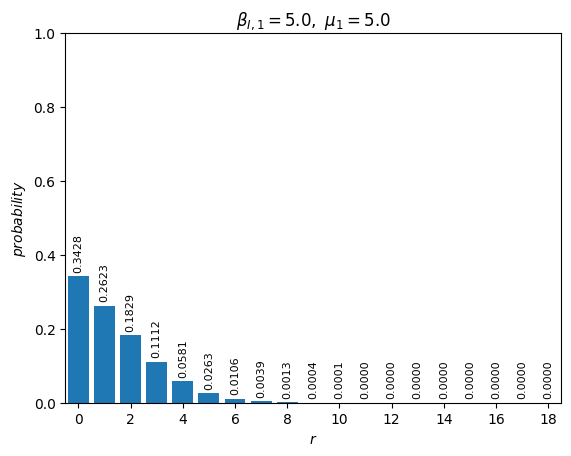

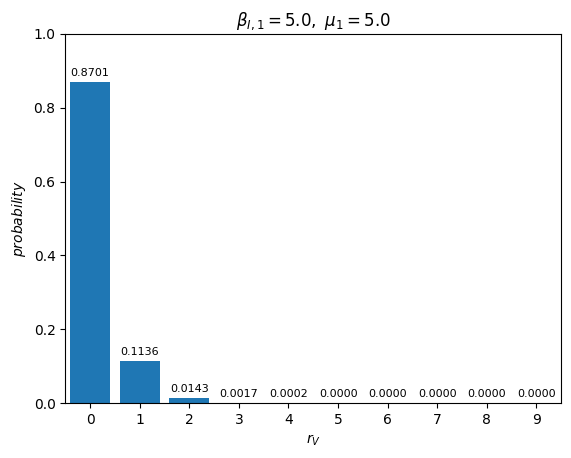

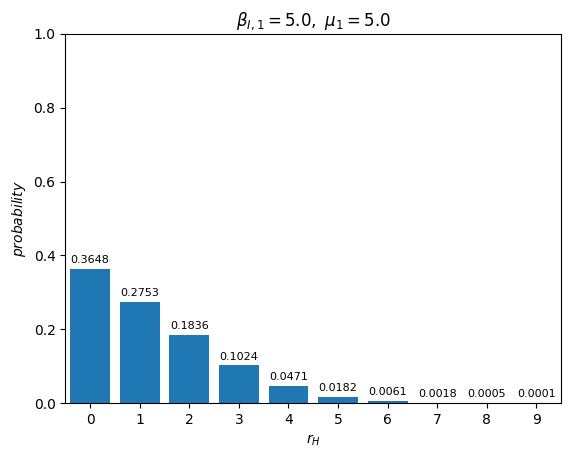

In [783]:
pmf_total(10,1,0)
pmf_vertical(10,1,0)
pmf_horizontal(10,1,0)